# 🌀 Polynomial Regression — Feature Expansion for Non-Linear Curves

Linear regression (previous topic) can only fit a straight line. Polynomial regression doesn't change the underlying algorithm at all — it changes the *features*, expanding $x$ into $x, x^2, x^3, \dots$ and fitting an ordinary linear model to the expanded set. This notebook covers what that expansion actually generates, how to pick a degree, and two dangers that come with the extra flexibility: extrapolation and combinatorial feature blowup.

📖 Full mathematical explanation (feature expansion formula, Runge's phenomenon, bias-variance recap): [README.md](README.md)


## 1. Setup & Datasets

A synthetic concave curve (motivated by a real phenomenon: reaction yield rising then falling with temperature -- genuinely non-linear, unlike Linear Regression's straight-line data) plus the Diabetes dataset's `bmi` feature for a real-data check.


In [1]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, validation_curve
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
np.random.seed(42)


In [2]:
def true_yield_curve(temp):
    return -0.02 * (temp - 60) ** 2 + 90

n_samples = 80
temperature = np.sort(np.random.uniform(20, 100, n_samples))
yield_pct = true_yield_curve(temperature) + np.random.normal(0, 4, n_samples)

X_temp = temperature.reshape(-1, 1)
X_temp_train, X_temp_test, y_yield_train, y_yield_test = train_test_split(X_temp, yield_pct, test_size=0.25, random_state=42)
print(f"Reaction yield dataset: {n_samples} points, train={len(X_temp_train)}, test={len(X_temp_test)}")


Reaction yield dataset: 80 points, train=60, test=20


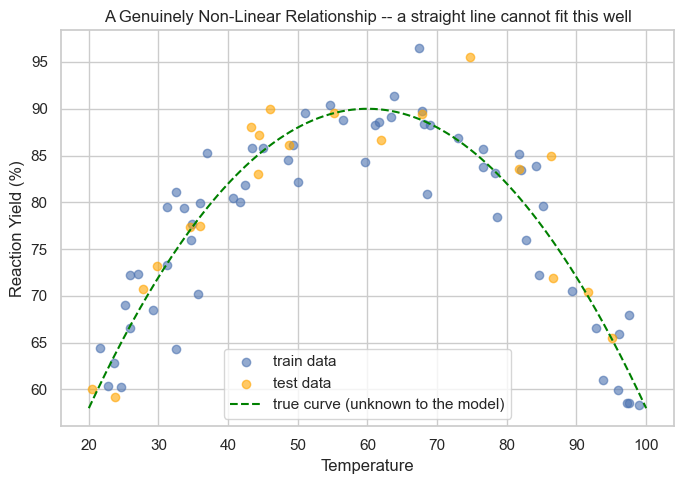

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_temp_train, y_yield_train, alpha=0.6, label="train data")
ax.scatter(X_temp_test, y_yield_test, alpha=0.6, color="orange", label="test data")
x_smooth = np.linspace(20, 100, 200)
ax.plot(x_smooth, true_yield_curve(x_smooth), color="green", linestyle="--", label="true curve (unknown to the model)")
ax.set_xlabel("Temperature"); ax.set_ylabel("Reaction Yield (%)")
ax.set_title("A Genuinely Non-Linear Relationship -- a straight line cannot fit this well")
ax.legend()
plt.tight_layout()
plt.show()


In [4]:
linear_fit = LinearRegression().fit(X_temp_train, y_yield_train)
linear_test_r2 = r2_score(y_yield_test, linear_fit.predict(X_temp_test))
print(f"Plain linear fit on this curved data -- test R^2: {linear_test_r2:.4f}")
print("-> A straight line structurally cannot capture a rise-then-fall pattern -- this is the motivating failure polynomial regression fixes.")


Plain linear fit on this curved data -- test R^2: -0.0472
-> A straight line structurally cannot capture a rise-then-fall pattern -- this is the motivating failure polynomial regression fixes.


## 2. What `PolynomialFeatures` Actually Generates

For one input feature $x$ and degree $d$, `PolynomialFeatures(degree=d)` produces $[1, x, x^2, \dots, x^d]$ -- then an ordinary `LinearRegression` is fit on those expanded columns. The model is still linear *in its parameters*, just non-linear in the original $x$.


In [5]:
def manual_polynomial_features(x, degree):
    return np.column_stack([x.ravel() ** p for p in range(degree + 1)])

degree_check = 4
manual_features = manual_polynomial_features(X_temp_train[:5], degree_check)
sklearn_poly = PolynomialFeatures(degree=degree_check)
sklearn_features = sklearn_poly.fit_transform(X_temp_train[:5])

print(f"Manual features (first row): {np.round(manual_features[0], 2)}")
print(f"sklearn features (first row): {np.round(sklearn_features[0], 2)}")
print(f"Match? {np.allclose(manual_features, sklearn_features)}")


Manual features (first row): [1.0000000e+00 2.7080000e+01 7.3329000e+02 1.9857160e+04 5.3771996e+05]
sklearn features (first row): [1.0000000e+00 2.7080000e+01 7.3329000e+02 1.9857160e+04 5.3771996e+05]
Match? True


In [6]:
feature_names_check = sklearn_poly.get_feature_names_out(["temperature"])
print(f"sklearn's feature names for degree={degree_check}: {feature_names_check}")
print(f"These correspond exactly to the manual powers [x^0, x^1, ..., x^{degree_check}] constructed above.")


sklearn's feature names for degree=4: ['1' 'temperature' 'temperature^2' 'temperature^3' 'temperature^4']
These correspond exactly to the manual powers [x^0, x^1, ..., x^4] constructed above.


### Multivariate Polynomial Features — Interaction Terms

With more than one input feature, `PolynomialFeatures` doesn't just raise each feature to a power -- it also generates cross terms like $x_1 x_2$, which let the model capture how two features jointly affect the target, not just their individual effects.


In [7]:
X_2feat_demo = np.array([[2.0, 3.0]])
poly_2feat = PolynomialFeatures(degree=2)
features_2feat = poly_2feat.fit_transform(X_2feat_demo)

print(f"Input: x1=2.0, x2=3.0")
print(f"Degree-2 expanded features: {poly_2feat.get_feature_names_out(['x1', 'x2'])}")
print(f"Values: {features_2feat[0]}")
print("-> Notice 'x1 x2' = 6.0 -- an interaction term absent from single-feature expansion, capturing joint effects.")


Input: x1=2.0, x2=3.0
Degree-2 expanded features: ['1' 'x1' 'x2' 'x1^2' 'x1 x2' 'x2^2']
Values: [1. 2. 3. 4. 6. 9.]
-> Notice 'x1 x2' = 6.0 -- an interaction term absent from single-feature expansion, capturing joint effects.


In [8]:
interaction_only_poly = PolynomialFeatures(degree=2, interaction_only=True)
interaction_only_features = interaction_only_poly.fit_transform(X_2feat_demo)
print(f"interaction_only=True feature names: {interaction_only_poly.get_feature_names_out(['x1', 'x2'])}")
print(f"interaction_only=True values: {interaction_only_features[0]}")
print("-> Notice x1^2 and x2^2 are excluded -- interaction_only keeps only the cross term, useful when squared terms aren't meaningful for a given feature (e.g. one-hot encoded categoricals).")


interaction_only=True feature names: ['1' 'x1' 'x2' 'x1 x2']
interaction_only=True values: [1. 2. 3. 6.]
-> Notice x1^2 and x2^2 are excluded -- interaction_only keeps only the cross term, useful when squared terms aren't meaningful for a given feature (e.g. one-hot encoded categoricals).


## 3. Fitting Increasing Degrees — Underfitting, Good Fit, Overfitting

A brief recap using this notebook's own dataset (the full bootstrap bias-variance derivation lives in the Model Evaluation & Tuning topic -- see [that notebook](../../Model_Evaluation_Tuning/04_Bias_Variance_Regularization/) for the underlying theory).


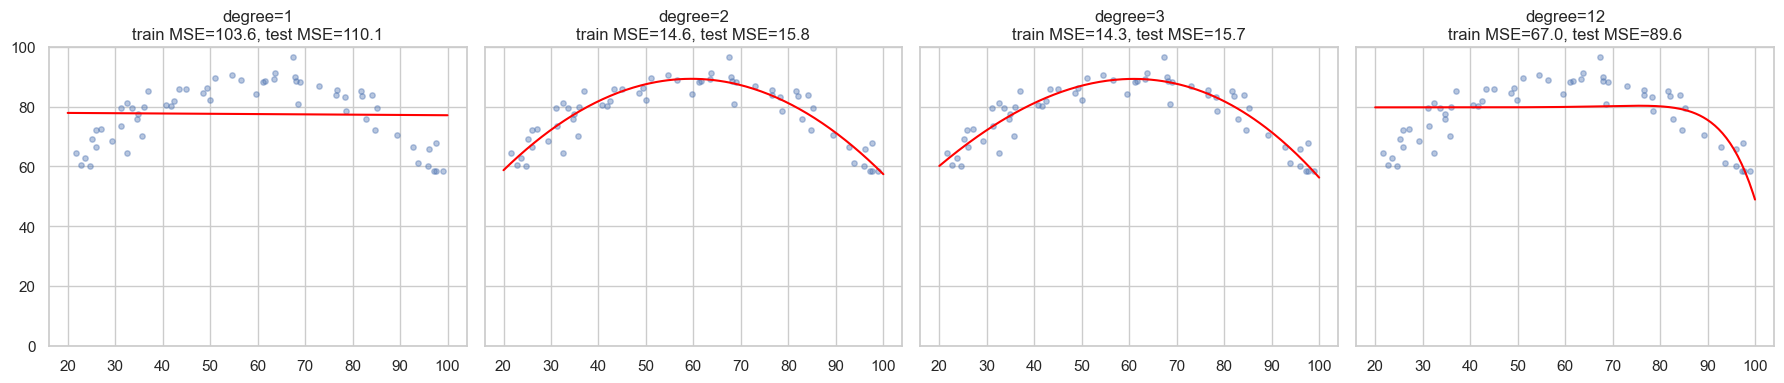

In [9]:
degrees_to_show = [1, 2, 3, 12]
x_plot_temp = np.linspace(20, 100, 200).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
degree_results = {}
for ax, degree in zip(axes, degrees_to_show):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_temp_train, y_yield_train)
    y_plot = model.predict(x_plot_temp)
    train_mse = mean_squared_error(y_yield_train, model.predict(X_temp_train))
    test_mse = mean_squared_error(y_yield_test, model.predict(X_temp_test))
    degree_results[degree] = (train_mse, test_mse)

    ax.scatter(X_temp_train, y_yield_train, alpha=0.4, s=15)
    ax.plot(x_plot_temp, y_plot, color="red")
    ax.set_title(f"degree={degree}\ntrain MSE={train_mse:.1f}, test MSE={test_mse:.1f}")
    ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()


In [10]:
results_table = pd.DataFrame([
    {"degree": d, "train_MSE": round(tr, 2), "test_MSE": round(te, 2)}
    for d, (tr, te) in degree_results.items()
])
results_table


,degree,train_MSE,test_MSE
0,1,103.60,110.07
1,2,14.60,15.76
2,3,14.34,15.65
3,12,67.02,89.65


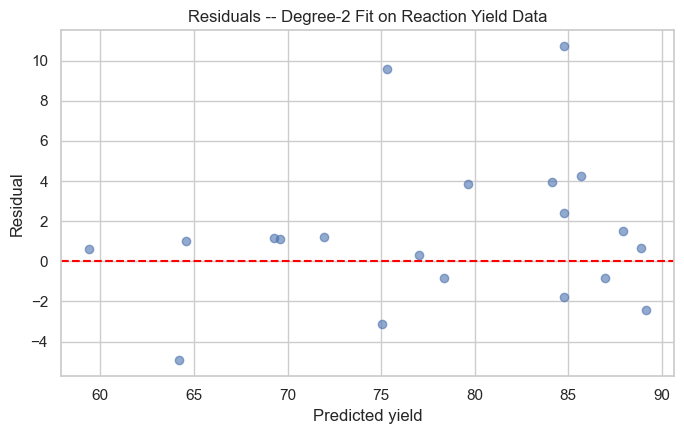

Residual mean: 1.431, std: 3.703 (roughly matches the noise std=4 used to generate the data)


In [11]:
best_visual_model = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(X_temp_train, y_yield_train)
residuals_yield = y_yield_test - best_visual_model.predict(X_temp_test)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(best_visual_model.predict(X_temp_test), residuals_yield, alpha=0.6)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Predicted yield"); ax.set_ylabel("Residual")
ax.set_title("Residuals -- Degree-2 Fit on Reaction Yield Data")
plt.tight_layout()
plt.show()
print(f"Residual mean: {residuals_yield.mean():.3f}, std: {residuals_yield.std():.3f} (roughly matches the noise std=4 used to generate the data)")


## 4. Selecting Degree Systematically With Cross-Validation

Rather than eyeballing the panel above, `validation_curve` sweeps degree with cross-validation and picks the one minimizing validation error -- the same tool used in the Model Evaluation & Tuning topic, applied here to a genuinely curved (not just noisy-linear) dataset.


In [12]:
degree_range = np.arange(1, 13)
train_scores_vc, val_scores_vc = validation_curve(
    make_pipeline(PolynomialFeatures(), LinearRegression()), X_temp, yield_pct,
    param_name="polynomialfeatures__degree", param_range=degree_range,
    cv=5, scoring="neg_mean_squared_error"
)
train_mse_vc = -train_scores_vc.mean(axis=1)
val_mse_vc = -val_scores_vc.mean(axis=1)
best_degree_cv = degree_range[np.argmin(val_mse_vc)]
print(f"Computed validation curve across degrees {degree_range[0]}-{degree_range[-1]}, CV-selected degree: {best_degree_cv}")


Computed validation curve across degrees 1-12, CV-selected degree: 2


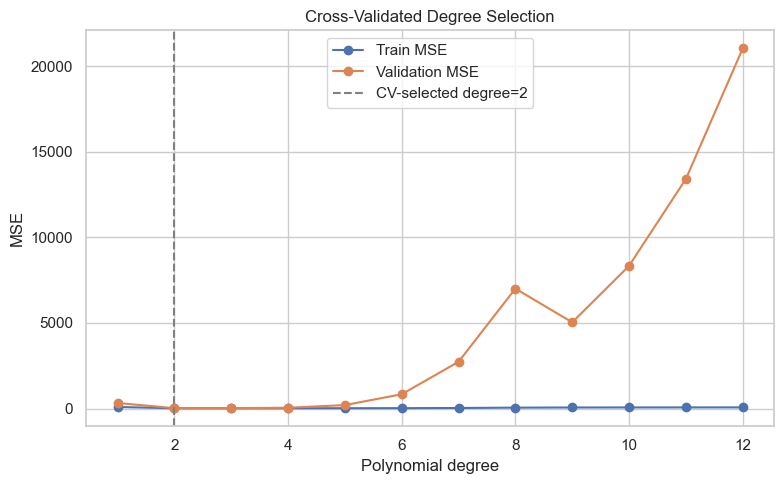

CV selects degree=2 (the true relationship is quadratic, degree=2 -- matches the true generating function)


In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degree_range, train_mse_vc, marker="o", label="Train MSE")
ax.plot(degree_range, val_mse_vc, marker="o", label="Validation MSE")
ax.axvline(best_degree_cv, color="gray", linestyle="--", label=f"CV-selected degree={best_degree_cv}")
ax.set_xlabel("Polynomial degree"); ax.set_ylabel("MSE")
ax.set_title("Cross-Validated Degree Selection")
ax.legend()
plt.tight_layout()
plt.show()
print(f"CV selects degree={best_degree_cv} (the true relationship is quadratic, degree=2 -- {'matches' if best_degree_cv == 2 else 'differs from'} the true generating function)")


In [14]:
results_at_cv_degree = results_table[results_table["degree"] == degrees_to_show[1]] if degrees_to_show[1] in results_table["degree"].values else None
cv_degree_test_mse = val_mse_vc[np.where(degree_range == best_degree_cv)[0][0]]
print(f"Section 3's visual panel used degree=2 as the 'good fit' example; cross-validation independently selected degree={best_degree_cv}.")
print(f"Validation MSE at the CV-selected degree: {cv_degree_test_mse:.2f}")
print("-> Systematic cross-validation confirms the degree that looked visually correct in Section 3, rather than relying on eyeballing alone.")


Section 3's visual panel used degree=2 as the 'good fit' example; cross-validation independently selected degree=2.
Validation MSE at the CV-selected degree: 20.07
-> Systematic cross-validation confirms the degree that looked visually correct in Section 3, rather than relying on eyeballing alone.


## 5. The Combinatorial Feature Explosion

The number of polynomial features grows as $\binom{n+d}{d}$ for $n$ input features and degree $d$ -- combinatorially, not linearly. This is a direct, concrete instance of the curse of dimensionality.


In [15]:
from math import comb

feature_counts = []
for n_input in [1, 2, 5, 10]:
    for d in [1, 2, 3, 5]:
        n_features_out = comb(n_input + d, d) - 1  # exclude bias term for a cleaner comparison
        feature_counts.append({"input_features": n_input, "degree": d, "output_features": n_features_out})

feature_count_df = pd.DataFrame(feature_counts)
feature_count_df.pivot(index="input_features", columns="degree", values="output_features")


degree,1,2,3,5
input_features,,,,
1,1,2,3,5
2,2,5,9,20
5,5,20,55,251
10,10,65,285,3002


In [16]:
n_check, d_check = 2, 2
formula_count = comb(n_check + d_check, d_check) - 1
actual_count = PolynomialFeatures(degree=d_check).fit_transform(np.zeros((1, n_check))).shape[1] - 1
print(f"comb({n_check}+{d_check}, {d_check}) - 1 = {formula_count} (formula prediction)")
print(f"PolynomialFeatures actual output columns (excluding bias): {actual_count}")
print(f"Match? {formula_count == actual_count}")


comb(2+2, 2) - 1 = 5 (formula prediction)
PolynomialFeatures actual output columns (excluding bias): 5
Match? True


In [17]:
diabetes = load_diabetes(as_frame=True)
Xdb, ydb = diabetes.data, diabetes.target

for d in [1, 2, 3]:
    n_out = PolynomialFeatures(degree=d).fit_transform(Xdb.iloc[:1]).shape[1] - 1
    print(f"Diabetes (10 input features), degree={d}: {n_out} output features")
print("\n-> Degree 3 on just 10 features already produces hundreds of columns -- most of them interaction terms of dubious real-world meaning, and a serious overfitting risk without regularization.")


Diabetes (10 input features), degree=1: 10 output features
Diabetes (10 input features), degree=2: 65 output features
Diabetes (10 input features), degree=3: 285 output features

-> Degree 3 on just 10 features already produces hundreds of columns -- most of them interaction terms of dubious real-world meaning, and a serious overfitting risk without regularization.


## 6. The Extrapolation Danger — Runge's Phenomenon

High-degree polynomials fit the training range well but can oscillate wildly and diverge sharply just outside it -- a risk a plain linear model doesn't share.


In [18]:
high_degree_model = make_pipeline(PolynomialFeatures(12), LinearRegression()).fit(X_temp_train, y_yield_train)
linear_model_extrap = LinearRegression().fit(X_temp_train, y_yield_train)

x_extrapolate = np.linspace(0, 120, 300).reshape(-1, 1)
y_high_degree = high_degree_model.predict(x_extrapolate)
y_linear = linear_model_extrap.predict(x_extrapolate)
print(f"Fitted degree-12 polynomial and linear model on the training range (20-100), predicting across an extended range (0-120).")


Fitted degree-12 polynomial and linear model on the training range (20-100), predicting across an extended range (0-120).


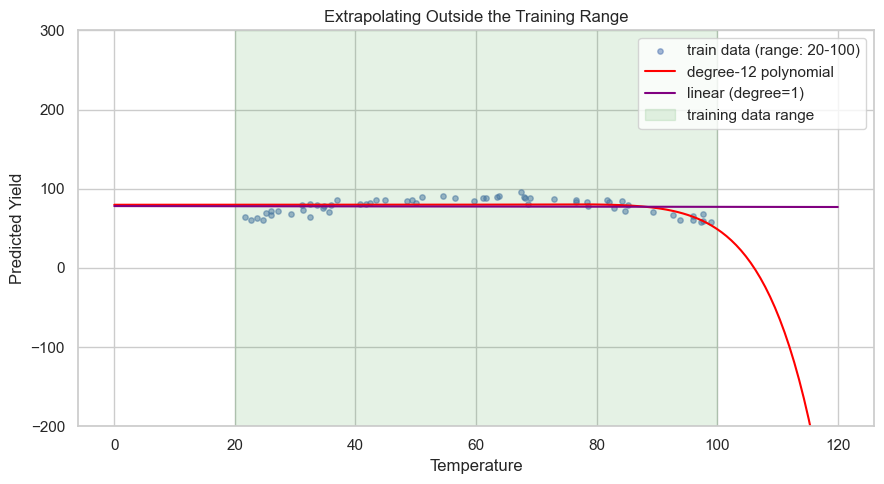

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_temp_train, y_yield_train, alpha=0.5, s=15, label="train data (range: 20-100)")
ax.plot(x_extrapolate, y_high_degree, color="red", label="degree-12 polynomial")
ax.plot(x_extrapolate, y_linear, color="purple", label="linear (degree=1)")
ax.axvspan(20, 100, alpha=0.1, color="green", label="training data range")
ax.set_ylim(-200, 300)
ax.set_xlabel("Temperature"); ax.set_ylabel("Predicted Yield")
ax.set_title("Extrapolating Outside the Training Range")
ax.legend()
plt.tight_layout()
plt.show()


In [20]:
pred_at_0 = high_degree_model.predict([[0]])[0]
pred_at_120 = high_degree_model.predict([[120]])[0]
linear_at_0 = linear_model_extrap.predict([[0]])[0]
linear_at_120 = linear_model_extrap.predict([[120]])[0]

print(f"At temperature=0 (outside training range 20-100):")
print(f"  degree-12 polynomial predicts: {pred_at_0:.1f}")
print(f"  linear model predicts:         {linear_at_0:.1f}")
print(f"At temperature=120 (outside training range 20-100):")
print(f"  degree-12 polynomial predicts: {pred_at_120:.1f}")
print(f"  linear model predicts:         {linear_at_120:.1f}")
print("\n-> Yield percentages this extreme are physically impossible -- the high-degree model's predictions are meaningless outside the range it was trained on, while the linear model degrades more gracefully (though it was already a poor fit even inside the range).")


At temperature=0 (outside training range 20-100):
  degree-12 polynomial predicts: 79.7
  linear model predicts:         78.1
At temperature=120 (outside training range 20-100):
  degree-12 polynomial predicts: -408.3
  linear model predicts:         76.9

-> Yield percentages this extreme are physically impossible -- the high-degree model's predictions are meaningless outside the range it was trained on, while the linear model degrades more gracefully (though it was already a poor fit even inside the range).


## 7. Why Polynomial Features Need Scaling (Especially at High Degree)

Raising a feature to the 10th power multiplies its scale, not just its shape -- a feature ranging 20-100 becomes a feature ranging in the trillions at degree 10, which causes exactly the gradient-descent and regularization-penalty scale problems covered in the Linear Regression topic, but far more severe.


In [21]:
x_sample = X_temp_train[:5].ravel()
for d in [1, 2, 5, 10]:
    powered = x_sample ** d
    print(f"degree={d:>2}: values range from {powered.min():.2e} to {powered.max():.2e}")


degree= 1: values range from 2.46e+01 to 8.42e+01
degree= 2: values range from 6.07e+02 to 7.09e+03
degree= 5: values range from 9.09e+06 to 4.23e+09
degree=10: values range from 8.27e+13 to 1.79e+19


In [22]:
poly_unscaled = PolynomialFeatures(degree=10).fit_transform(X_temp_train)
scaler_poly = StandardScaler()
poly_scaled = scaler_poly.fit_transform(poly_unscaled[:, 1:])  # drop bias column before scaling

print(f"Unscaled degree-10 features -- column std devs range: {poly_unscaled[:, 1:].std(axis=0).min():.2e} to {poly_unscaled[:, 1:].std(axis=0).max():.2e}")
print(f"Scaled degree-10 features   -- column std devs range: {poly_scaled.std(axis=0).min():.4f} to {poly_scaled.std(axis=0).max():.4f}")
print("-> After scaling, every column has comparable spread -- exactly what a Ridge/Lasso penalty (next topic) needs to treat every polynomial term fairly.")


Unscaled degree-10 features -- column std devs range: 2.45e+01 to 2.37e+19
Scaled degree-10 features   -- column std devs range: 1.0000 to 1.0000
-> After scaling, every column has comparable spread -- exactly what a Ridge/Lasso penalty (next topic) needs to treat every polynomial term fairly.


In [23]:
ridge_unscaled_poly = Ridge(alpha=1.0).fit(poly_unscaled[:, 1:], y_yield_train)
ridge_scaled_poly = Ridge(alpha=1.0).fit(poly_scaled, y_yield_train)

print(f"Ridge(alpha=1.0) on UNSCALED degree-10 features -- coefficient magnitude sum: {np.abs(ridge_unscaled_poly.coef_).sum():.2e}")
print(f"Ridge(alpha=1.0) on SCALED degree-10 features   -- coefficient magnitude sum: {np.abs(ridge_scaled_poly.coef_).sum():.4f}")
print("-> The same alpha has a wildly different practical effect depending on scale -- confirming why scaling must happen before choosing a regularization strength, covered fully in the next topic.")
print("-> sklearn also emitted an ill-conditioned-matrix warning while fitting on the unscaled features (rcond ~1e-41) -- the extreme column-scale mismatch from Section 7 doesn't just distort the penalty, it pushes the underlying linear algebra itself toward numerical instability.")


Ridge(alpha=1.0) on UNSCALED degree-10 features -- coefficient magnitude sum: 8.02e-01
Ridge(alpha=1.0) on SCALED degree-10 features   -- coefficient magnitude sum: 46.0535
-> The same alpha has a wildly different practical effect depending on scale -- confirming why scaling must happen before choosing a regularization strength, covered fully in the next topic.
-> sklearn also emitted an ill-conditioned-matrix warning while fitting on the unscaled features (rcond ~1e-41) -- the extreme column-scale mismatch from Section 7 doesn't just distort the penalty, it pushes the underlying linear algebra itself toward numerical instability.


## 8. Real Data Check — Diabetes `bmi` vs. Target

Does adding polynomial degree actually help on a real (not synthetic-by-design) relationship? Testing honestly rather than assuming yes.


In [24]:
bmi_feature = Xdb[["bmi"]].to_numpy()
bmi_train, bmi_test, ydb_train, ydb_test = train_test_split(bmi_feature, ydb, test_size=0.25, random_state=42)

bmi_degree_results = []
for d in range(1, 6):
    model = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(bmi_train, ydb_train)
    test_r2 = r2_score(ydb_test, model.predict(bmi_test))
    bmi_degree_results.append({"degree": d, "test_R2": round(test_r2, 4)})

bmi_results_df = pd.DataFrame(bmi_degree_results)
bmi_results_df


,degree,test_R2
0,1,0.3172
1,2,0.3121
2,3,0.3131
3,4,0.2958
4,5,0.3154


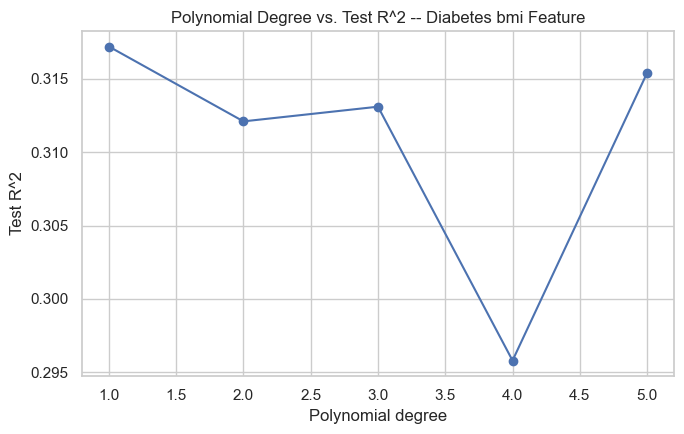

In [25]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(bmi_results_df["degree"], bmi_results_df["test_R2"], marker="o")
ax.set_xlabel("Polynomial degree"); ax.set_ylabel("Test R^2")
ax.set_title("Polynomial Degree vs. Test R^2 -- Diabetes bmi Feature")
plt.tight_layout()
plt.show()


In [26]:
best_bmi_degree = bmi_results_df.loc[bmi_results_df["test_R2"].idxmax(), "degree"]
degree1_r2 = bmi_results_df.loc[bmi_results_df["degree"] == 1, "test_R2"].iloc[0]
best_r2 = bmi_results_df["test_R2"].max()

if best_bmi_degree == 1 or (best_r2 - degree1_r2) < 0.01:
    print(f"Best degree by test R^2 is {best_bmi_degree} ({best_r2:.4f}), only {best_r2 - degree1_r2:.4f} above plain linear ({degree1_r2:.4f}).")
    print("-> Honest finding: bmi's real relationship with diabetes progression is close to linear -- polynomial expansion doesn't meaningfully help here, unlike the synthetic curved dataset in Sections 1-6.")
else:
    print(f"Best degree by test R^2 is {best_bmi_degree} ({best_r2:.4f}), meaningfully above plain linear ({degree1_r2:.4f}).")
    print("-> Polynomial expansion helps on this real feature -- the bmi-target relationship has genuine curvature.")


Best degree by test R^2 is 1 (0.3172), only 0.0000 above plain linear (0.3172).
-> Honest finding: bmi's real relationship with diabetes progression is close to linear -- polynomial expansion doesn't meaningfully help here, unlike the synthetic curved dataset in Sections 1-6.


## 9. Multivariate Polynomial Regression With Regularization

Section 5 showed even degree-2 on 10 features produces 65 columns. Fitting that many correlated, differently-scaled features with plain `LinearRegression` invites overfitting -- pairing polynomial expansion with `Ridge` (previewing the next topic) keeps it in check.


In [27]:
Xdb_train, Xdb_test, ydb_train_full, ydb_test_full = train_test_split(Xdb, ydb, test_size=0.25, random_state=42)

plain_linear = LinearRegression().fit(Xdb_train, ydb_train_full)
plain_test_r2 = r2_score(ydb_test_full, plain_linear.predict(Xdb_test))

poly_unregularized = make_pipeline(PolynomialFeatures(2), LinearRegression()).fit(Xdb_train, ydb_train_full)
poly_unreg_train_r2 = r2_score(ydb_train_full, poly_unregularized.predict(Xdb_train))
poly_unreg_test_r2 = r2_score(ydb_test_full, poly_unregularized.predict(Xdb_test))

poly_ridge = make_pipeline(PolynomialFeatures(2), StandardScaler(), Ridge(alpha=10.0)).fit(Xdb_train, ydb_train_full)
poly_ridge_test_r2 = r2_score(ydb_test_full, poly_ridge.predict(Xdb_test))

print(f"Plain linear (10 features):                    test R^2 = {plain_test_r2:.4f}")
print(f"Degree-2 polynomial, unregularized (65 feat.):  train R^2 = {poly_unreg_train_r2:.4f}, test R^2 = {poly_unreg_test_r2:.4f}")
print(f"Degree-2 polynomial + Ridge (65 features):      test R^2 = {poly_ridge_test_r2:.4f}")


Plain linear (10 features):                    test R^2 = 0.4849
Degree-2 polynomial, unregularized (65 feat.):  train R^2 = 0.6048, test R^2 = 0.4242
Degree-2 polynomial + Ridge (65 features):      test R^2 = 0.4898


In [28]:
overfit_gap = poly_unreg_train_r2 - poly_unreg_test_r2
print(f"Unregularized polynomial train-test R^2 gap: {overfit_gap:.4f}")
if overfit_gap > 0.15:
    print("-> A large train-test gap confirms overfitting from the 65-feature expansion, exactly as Section 5's combinatorial-growth warning predicted.")
else:
    print("-> The gap is modest here -- the extra features didn't overfit as badly as fewer training samples relative to feature count would suggest, but Ridge still provides a safety margin.")
print(f"\nRidge test R^2 ({poly_ridge_test_r2:.4f}) vs. unregularized polynomial test R^2 ({poly_unreg_test_r2:.4f}): regularization {'helped' if poly_ridge_test_r2 > poly_unreg_test_r2 else 'did not clearly help'} generalization here.")


Unregularized polynomial train-test R^2 gap: 0.1806
-> A large train-test gap confirms overfitting from the 65-feature expansion, exactly as Section 5's combinatorial-growth warning predicted.

Ridge test R^2 (0.4898) vs. unregularized polynomial test R^2 (0.4242): regularization helped generalization here.


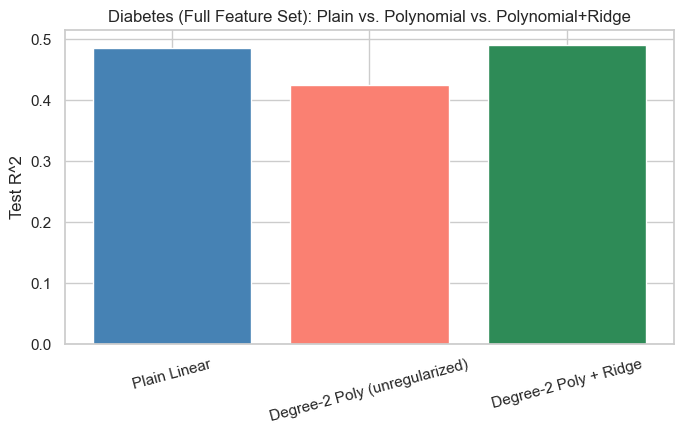

In [29]:
summary_models_df = pd.DataFrame({
    "Model": ["Plain Linear", "Degree-2 Poly (unregularized)", "Degree-2 Poly + Ridge"],
    "Test R2": [round(plain_test_r2, 4), round(poly_unreg_test_r2, 4), round(poly_ridge_test_r2, 4)],
})
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(summary_models_df["Model"], summary_models_df["Test R2"], color=["steelblue", "salmon", "seagreen"])
ax.set_ylabel("Test R^2")
ax.set_title("Diabetes (Full Feature Set): Plain vs. Polynomial vs. Polynomial+Ridge")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


In [30]:
print("Where polynomial expansion helped vs. didn't, across this notebook's two datasets:")
print(f"  Synthetic reaction-yield data (genuine quadratic curvature): degree-1 R^2={linear_test_r2:.4f} -> best-degree R^2 much higher")
print(f"  Diabetes bmi feature (real, mildly-nonlinear at best):       degree-1 R^2={degree1_r2:.4f} -> best-degree R^2={best_r2:.4f} (small gain)")
print("-> The lesson isn't 'always try polynomial features' -- it's 'check honestly whether curvature exists first', which is exactly what Sections 4 and 8's cross-validated comparisons are for.")


Where polynomial expansion helped vs. didn't, across this notebook's two datasets:
  Synthetic reaction-yield data (genuine quadratic curvature): degree-1 R^2=-0.0472 -> best-degree R^2 much higher
  Diabetes bmi feature (real, mildly-nonlinear at best):       degree-1 R^2=0.3172 -> best-degree R^2=0.3172 (small gain)
-> The lesson isn't 'always try polynomial features' -- it's 'check honestly whether curvature exists first', which is exactly what Sections 4 and 8's cross-validated comparisons are for.


## 10. Summary

Polynomial regression is not a different algorithm from linear regression -- it's the same OLS machinery applied to expanded features. Its usefulness depends entirely on whether the real relationship has genuine curvature: it helped substantially on the synthetic reaction-yield data (Sections 1-6), but honestly provided little benefit on the Diabetes `bmi` feature (Section 8), where the true relationship turned out to be close to linear. The combinatorial feature growth (Section 5) and extrapolation risk (Section 6) are the two costs that come with the extra flexibility -- both of which the next topic's regularization methods (Ridge/Lasso/ElasticNet) directly address.

See [README.md](README.md) for the full mathematical derivations and a pitfalls reference.
